#### 로지스틱 회귀
선형회귀식을 이용해서 회귀라는 단어가 있지만 실제로는 분류에 대한 확률을 계산하는 모델

In [3]:
import pandas as pd
fish = pd.read_csv('data/fishes.csv')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [4]:
fish.Species.unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

### Feature, Target 분리

In [15]:
# Feature
# fish_input = fish[['Weight', 'Length','Diagonal','Height','Width']].to_numpy()
fish_input = fish[fish.columns[1:]].to_numpy()
fish_input[:5]
# Target
fish_target = fish['Species'].to_numpy()
fish_target[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

### train test로 분리

In [19]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_input,
        fish_target,
        random_state=42
    )

#### 표준화 시키기
각 컬럼별 데이터 크기 차이가 많이 나는 경우 반드시 처리

In [23]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)
train_scaled[:5]

array([[ 0.91965782,  0.60943175,  0.81041221,  1.85194896,  1.00075672],
       [ 0.30041219,  1.54653445,  1.45316551, -0.46981663,  0.27291745],
       [-1.0858536 , -1.68646987, -1.70848587, -1.70159849, -2.0044758 ],
       [-0.79734143, -0.60880176, -0.67486907, -0.82480589, -0.27631471],
       [-0.71289885, -0.73062511, -0.70092664, -0.0802298 , -0.7033869 ]])

#### KNN을 이용한 확률 예측

In [24]:
from sklearn.neighbors import KNeighborsClassifier

In [27]:
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print('train: ',kn.score(train_scaled, train_target))
print('test: ',kn.score(test_scaled, test_target))

train:  0.8907563025210085
test:  0.85


In [28]:
kn.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

In [29]:
import numpy as np
prob = kn.predict_proba(test_scaled[:5])
np.round(prob, decimals=4)

array([[0.    , 0.    , 1.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ]])

knn은 이웃의 갯수를 정하는 모델
현재 이웃의 갯수를 3으로 정했기 때문에 확룰에 나올 수 있는 경우의 수는 3이다 > 확률로 하기에는 좀 ....

#### 로지스틱 회귀를 이용한 확률 예측
- z = a무게 + b길이 + c대각선 + d높이 + e두께 + f로 구성
- z식을 이용하면 결과 값이 -무한대 ~ +무한대 범위로 출력, 이를 **Sigmoid** 함수를 활용해서 해결한다.
- Sigmoid 함수는 결과값이 0~1 사이의 수만 출력하므로 0.5를 기준으로 양성과 음성으로 분류
- 로지스틱 회귀를 사용할 경우 Sigmoid 함수를 로지스틱함수라고 표현

#### Sigmoid Graph 출력

In [30]:
import matplotlib.pyplot as plt

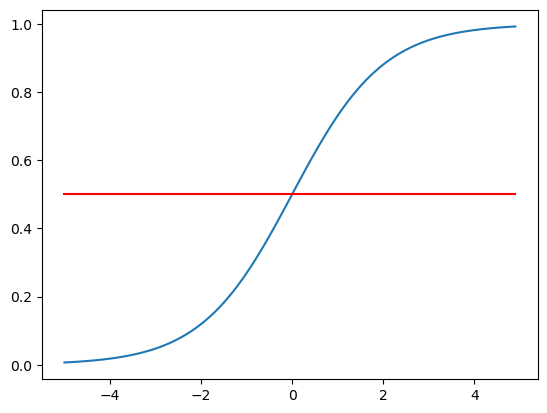

In [34]:
z = np.arange(-5, 5, 0.1)
y = np.full((100,1), 0.5)
phi = 1 / (1+np.exp(-z))

plt.plot(z, phi)
plt.plot(z, y, c='red')
plt.show()

#### 로지스틱 회귀로 이진분류 수행하기

In [37]:
# 2종류의 데이터만 발최하기
bream_smelt_indexes = (train_target == "Bream") | (train_target == "Smelt")
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]
print(train_bream_smelt[:5])
print(target_bream_smelt[:5])

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [ 0.63818253  0.56257661  0.73223951  1.64473401  0.50705737]
 [ 0.30041219  0.23459067  0.42823457  1.36042157  0.22329758]
 [ 0.9027693   0.70314202  0.88858491  1.89027545  0.85537174]]
['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [38]:
# 로지스틱 회귀 실행
from sklearn.linear_model import LogisticRegression

In [39]:
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)
lr.predict(train_bream_smelt[:5])

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream'], dtype=object)

In [41]:
lr.predict_proba(train_bream_smelt[:5]) # Bream, Smelt

array([[0.99760007, 0.00239993],
       [0.02737325, 0.97262675],
       [0.99486386, 0.00513614],
       [0.98585047, 0.01414953],
       [0.99767419, 0.00232581]])

#### 로지스틱 회귀로 다중회귀 분류하기

In [43]:
lr = LogisticRegression(C=20, max_iter=1000) # 기본값: C=1(작운수가 규제가 큼), max_iter(반복)=100
lr.fit(train_scaled, train_target)
print('Train: ', lr.score(train_scaled, train_target))
print('Test: ', lr.score(test_scaled, test_target))

Train:  0.9327731092436975
Test:  0.925


In [47]:
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [45]:
lr.predict(train_scaled[:5])

array(['Bream', 'Pike', 'Smelt', 'Perch', 'Parkki'], dtype=object)

In [49]:
proba = lr.predict_proba(test_scaled[:5])
np.round(proba, decimals=3)

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])